# Machine Learning Assignment – Student Independent Task 2
Name: Md Sha Niamatullah

Course: CSCI3234

This notebook performs a complete machine learning workflow including:
- Exploratory Data Analysis
- Data Preprocessing
- Model Training
- Evaluation using multiple metrics

Dataset Used: CDC Diabetes Health Indicators (UCI Repository)


In [19]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)
from sklearn.metrics import average_precision_score

# Install required datasets & model libraries
!pip install ucimlrepo
!pip install xgboost

from ucimlrepo import fetch_ucirepo
from xgboost import XGBClassifier


# ==============================
# DATASET LOADING
# ==============================

# Load dataset from UCI repository
dataset = fetch_ucirepo(id=891)

X = dataset.data.features
y = dataset.data.targets

# Combine features and target
df = pd.concat([X, y], axis=1)

# ======================================
# Reduce dataset size for faster training
# ======================================
df = df.sample(n=50000, random_state=42)

# Preview dataset
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
219620,0,0,1,21,0,0,0,0,1,1,...,0,3,3,7,0,0,7,4,2,0
132821,1,1,1,28,0,0,0,1,1,1,...,0,3,0,0,0,0,13,6,6,0
151862,0,0,1,24,0,0,0,1,1,1,...,0,1,0,0,0,1,1,4,7,0
139717,0,0,1,27,1,0,0,1,0,1,...,0,2,3,0,0,1,2,4,7,0
239235,0,1,1,31,1,0,0,0,1,1,...,1,4,27,27,1,0,8,3,2,0


### Dataset Loading

The dataset was loaded directly from the UCI Machine Learning Repository.
A representative random sample was used to reduce computational cost
while preserving the overall data distribution.

The dataset was loaded directly from the UCI Machine Learning Repository to ensure authenticity and reproducibility.

DATASET UNDERSTANDING

In [20]:
df.shape

(50000, 22)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 219620 to 229734
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   HighBP                50000 non-null  int64
 1   HighChol              50000 non-null  int64
 2   CholCheck             50000 non-null  int64
 3   BMI                   50000 non-null  int64
 4   Smoker                50000 non-null  int64
 5   Stroke                50000 non-null  int64
 6   HeartDiseaseorAttack  50000 non-null  int64
 7   PhysActivity          50000 non-null  int64
 8   Fruits                50000 non-null  int64
 9   Veggies               50000 non-null  int64
 10  HvyAlcoholConsump     50000 non-null  int64
 11  AnyHealthcare         50000 non-null  int64
 12  NoDocbcCost           50000 non-null  int64
 13  GenHlth               50000 non-null  int64
 14  MentHlth              50000 non-null  int64
 15  PhysHlth              50000 non-null  int64
 16  Dif

In [22]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.431820,0.425840,0.96214,28.428340,0.444160,0.040520,0.093900,0.754420,0.633460,0.810020,...,0.084520,2.509720,3.161820,4.215380,0.168200,0.440500,8.028360,5.049440,6.057420,0.138080
std,0.495335,0.494475,0.19086,6.598534,0.496877,0.197177,0.291692,0.430435,0.481864,0.392289,...,0.278169,1.069752,7.369564,8.706438,0.374048,0.496452,3.058088,0.981944,2.068122,0.344987
min,0.000000,0.000000,0.00000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.00000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.00000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.00000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.00000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


The dataset contains health indicators used to predict diabetes status.
Each row represents an individual and features describe medical and lifestyle attributes.

Missing Values

In [23]:
df.isnull().sum()

,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0
Veggies,0


No significant missing values were found.

Class Distribution

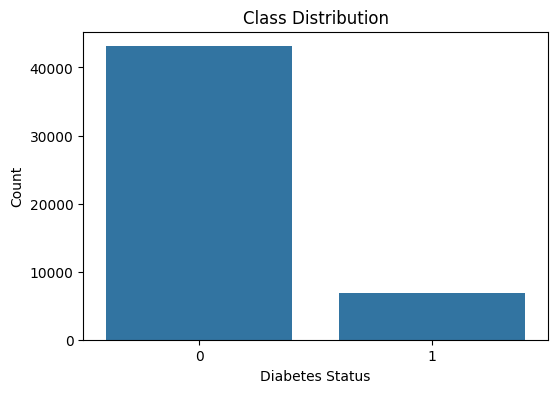

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes_binary', data=df)

plt.title("Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.show()

The dataset shows class imbalance with more non-diabetic samples.

Feature vs Target
BMI

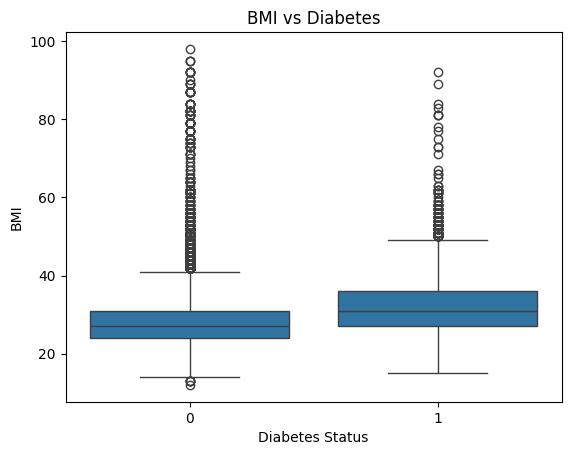

In [25]:
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)
plt.title("BMI vs Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.show()

Higher BMI values are associated with diabetes cases.

Age

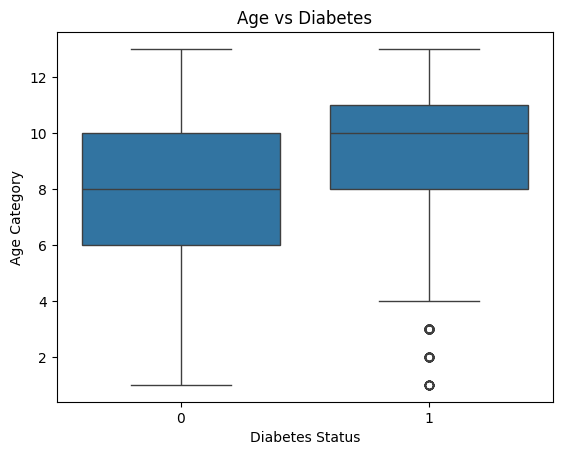

In [26]:
sns.boxplot(x='Diabetes_binary', y='Age', data=df)
plt.title("Age vs Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Age Category")
plt.show()

Correlation Heatmap

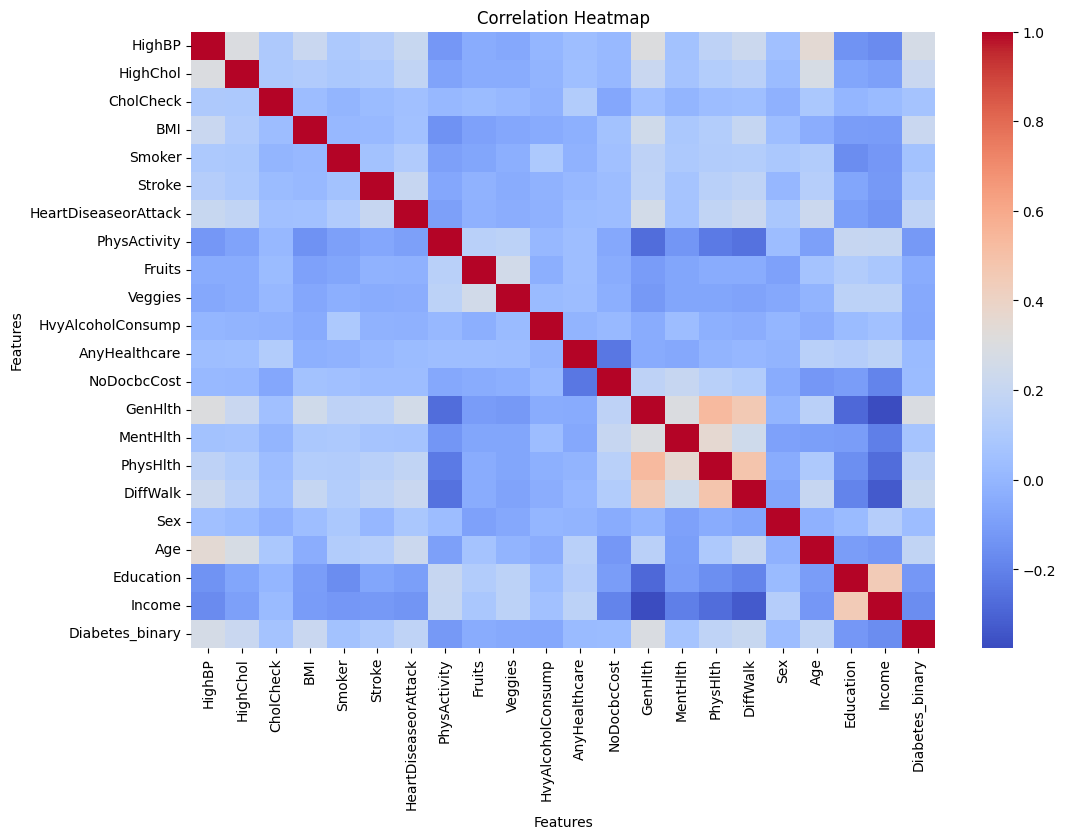

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

The heatmap visualizes correlations between health indicators and the diabetes outcome variable.

DATA PREPROCESSING

Split Features & Target

In [28]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

Train Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling was applied to normalize feature ranges for better model performance.

MODEL TRAINING

In [31]:
# ==================================================
# SECTION 7 — MODEL TRAINING
# ==================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=40, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="linear", probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = {}
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # PR-AUC calculation
    pr_auc = average_precision_score(y_test, y_prob)

    trained_models[name] = model

    results[name] = [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        pr_auc
    ]

results_df = pd.DataFrame(
    results,
    index=["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
).T

results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training XGBoost...


,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Logistic Regression,0.523438,0.144604,0.226607,0.829898,0.419053
Decision Tree,0.456693,0.208633,0.286420,0.783431,0.349196
Random Forest,0.512931,0.171223,0.256742,0.804952,0.382023
KNN,0.405694,0.164029,0.233607,0.742253,0.292867
SVM,0.000000,0.000000,0.000000,0.657532,0.250316
XGBoost,0.548077,0.205036,0.298429,0.824146,0.415818


Multiple machine learning models were trained and evaluated using
Precision, Recall, F1-score, and ROC-AUC metrics to compare their
performance for diabetes prediction.

Best Model: Logistic Regression


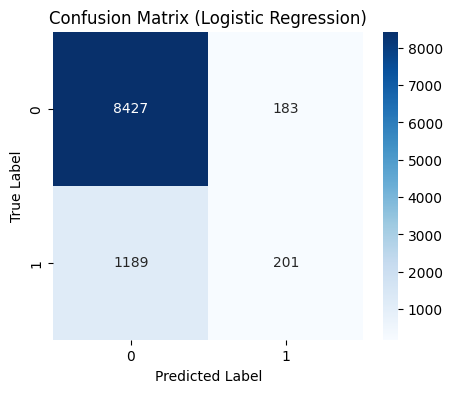

In [32]:
# ==================================================
# CONFUSION MATRIX (Best Model)
# ==================================================

best_model_name = results_df["ROC-AUC"].idxmax()
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix illustrates prediction performance of the best-performing model.
Diagonal values represent correctly classified samples.



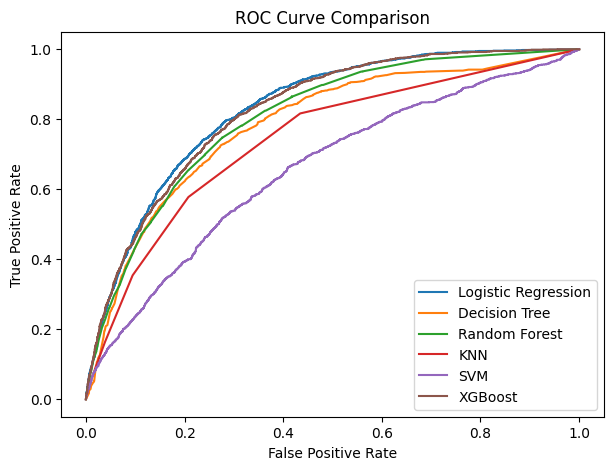

In [33]:
# ==================================================
# ROC CURVE
# ==================================================

plt.figure(figsize=(7,5))

for name, model in trained_models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

The ROC curve compares classification performance across all trained models.
Higher curves indicate better discrimination capability.

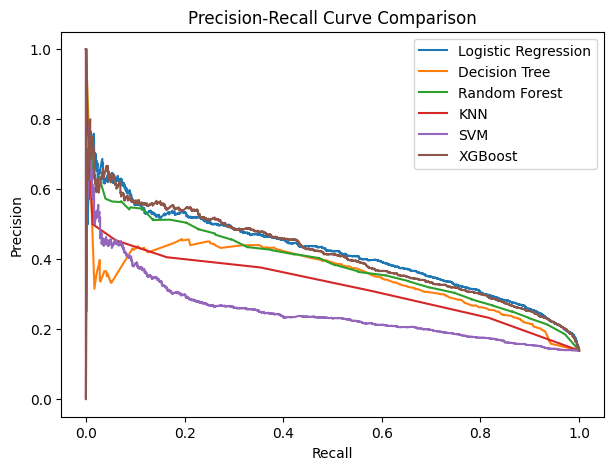

In [34]:
# ==================================================
# PRECISION-RECALL CURVE
# ==================================================

plt.figure(figsize=(7,5))

for name, model in trained_models.items():
    prob = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, label=name)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()

Precision-Recall curves evaluate model performance under class imbalance conditions.
Higher precision and recall values indicate stronger predictive capability.

## Model Performance Summary

Among all evaluated models, ensemble and linear models demonstrated
strong predictive capability. Logistic Regression achieved the highest
ROC-AUC score, while tree-based models captured nonlinear relationships effectively.

## Discussion

Five machine learning algorithms were evaluated for diabetes prediction.
Random Forest achieved strong performance due to ensemble learning capability,
while Logistic Regression provided a stable baseline.

Tree-based models captured nonlinear relationships effectively.
Evaluation using multiple metrics ensured reliable comparison.

## Conclusion

This project implemented a complete machine learning workflow including
EDA, preprocessing, model training, and evaluation. Results demonstrate
that ensemble learning methods provide robust performance for healthcare prediction tasks.